# Experiment 2 versus Experiment 3 personalized aging

This notebook compares Experiment 2 population aging against the single Experiment 3 baseline-modulated aging model. It covers diagnosis prediction, population and individual age speed, decoder-induced shape speed, exact age composition, full direct/composed consistency, modulation distributions, and optional one-/two-/three-shot forecasting.

Both models infer disease from the fitted test anchor. Experiment 3 additionally computes one fixed 16D age modulation from that anchor. True test diagnosis is used only after prediction to compute metrics.

$$m_i=1+0.5\tanh(H_m(\operatorname{sg}(z_i^0)))$$

$$\Delta_a^{pop}=W_a[e(t)-e(s)],\qquad \Delta_a^{ind}=W_a[(m_i-1)\odot(e(t)-e(s))].$$

Population and individual age are two terms inside the same 64D age block. They are not additional latent dimensions.

In [1]:
import importlib
import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

ROOT = Path('/home/jakaria/INR/Deep3DComp')
sys.path.insert(0, str(ROOT))
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

EXP2_EXP = ROOT / 'examples/Torus_subset_100_id_age_progression/velocity_64_160_32_baseline_dx'
E3_EXP = ROOT / 'examples/Torus_subset_100_id_age_progression/velocity_64_160_32_e3_personal'
EXP2_CHECKPOINT = 'latest'
E3_CHECKPOINT = 'latest'
AGE_START = 0.5
AGE_STEP = 0.01
NUM_NEAR_SURFACE = 2048
RANDOM_CANDIDATES = 100000
torch.manual_seed(7)
np.random.seed(7)
print('device:', DEVICE)

device: cuda


## Load models and checkpoint-specific mean anchors

If a checkpoint does not exist yet, the cell reports the intended configuration and later comparison cells skip that model.

In [2]:
def strip_module_prefix(state):
    return {k[7:] if k.startswith('module.') else k: v for k, v in state.items()}

def load_latent_mean(exp_dir, checkpoint):
    path = exp_dir / 'LatentCodes' / f'{checkpoint}.pth'
    data = torch.load(path, map_location='cpu')
    codes = data['latent_codes']
    if isinstance(codes, dict):
        codes = codes['weight']
    if codes.ndim == 3:
        codes = codes[:, 0, :]
    return codes.float().mean(dim=0, keepdim=True).to(DEVICE), codes.float()

def load_experiment(exp_dir, checkpoint, flow_module_name):
    spec = json.loads((exp_dir / 'specs.json').read_text())
    model_path = exp_dir / 'ModelParameters' / f'{checkpoint}.pth'
    latent_path = exp_dir / 'LatentCodes' / f'{checkpoint}.pth'
    if not model_path.exists() or not latent_path.exists():
        print(f'checkpoint unavailable: {model_path}')
        return {'spec': spec, 'available': False, 'exp_dir': exp_dir}
    decoder_module = importlib.import_module('networks.' + spec['NetworkArch'])
    decoder = decoder_module.Decoder(spec['CodeLength'], **spec['NetworkSpecs']).to(DEVICE)
    flow_module = importlib.import_module(flow_module_name)
    flow = flow_module.build_temporal_flow(
        spec, spec['CodeLength'], spec['FlowHiddenDims'],
        age_condition_dim=spec.get('AgeConditionDim', 0),
    ).to(DEVICE)
    data = torch.load(model_path, map_location='cpu')
    decoder.load_state_dict(strip_module_prefix(data['model_state_dict']))
    flow.load_state_dict(strip_module_prefix(data['flow_state_dict']))
    decoder.eval(); flow.eval()
    mean_z, all_z = load_latent_mean(exp_dir, checkpoint)
    return {
        'spec': spec, 'decoder': decoder, 'flow': flow,
        'mean_z': mean_z, 'all_z': all_z, 'available': True,
        'epoch': data.get('epoch'), 'exp_dir': exp_dir,
    }

exp2_model = load_experiment(
    EXP2_EXP, EXP2_CHECKPOINT,
    'networks.longitudinal_flow_64_160_32_pred_dx',
)
e3_model = load_experiment(
    E3_EXP, E3_CHECKPOINT,
    'networks.longitudinal_flow_64_160_32_personal_age',
)
models = {
    'exp2_population_age': exp2_model,
    'exp3_personalized_age': e3_model,
}
for name, model in models.items():
    spec = model['spec']
    print(name, 'available=', model['available'], 'blocks=', (
        spec.get('VelocityAgeDim'), spec.get('VelocityDiseaseDim'),
        spec.get('VelocityResidualDim')))

exp2_population_age available= True blocks= (64, 160, 32)
exp3_personalized_age available= True blocks= (64, 160, 32)


## Diagnosis prediction

Both trainers write `train_epoch_*.csv` and `test_epoch_*.csv`. Compare Experiment 2 and Experiment 3 on the same test subjects; neither model receives test diagnosis during inference.

exp2/train train_epoch_2000.csv {'accuracy': 1.0, 'balanced_accuracy': 1.0, 'auc': 1.0, 'sensitivity': 1.0, 'specificity': 1.0}
exp2/test test_epoch_2000.csv {'accuracy': 0.6666666666666666, 'balanced_accuracy': 0.6666666666666666, 'auc': 0.7407407407407407, 'sensitivity': 0.6666666666666666, 'specificity': 0.6666666666666666}
exp3/train train_epoch_1500.csv {'accuracy': 1.0, 'balanced_accuracy': 1.0, 'auc': 1.0, 'sensitivity': 1.0, 'specificity': 1.0}
exp3/test test_epoch_1500.csv {'accuracy': 0.8, 'balanced_accuracy': 0.7777777777777777, 'auc': 0.7962962962962963, 'sensitivity': 0.8888888888888888, 'specificity': 0.6666666666666666}


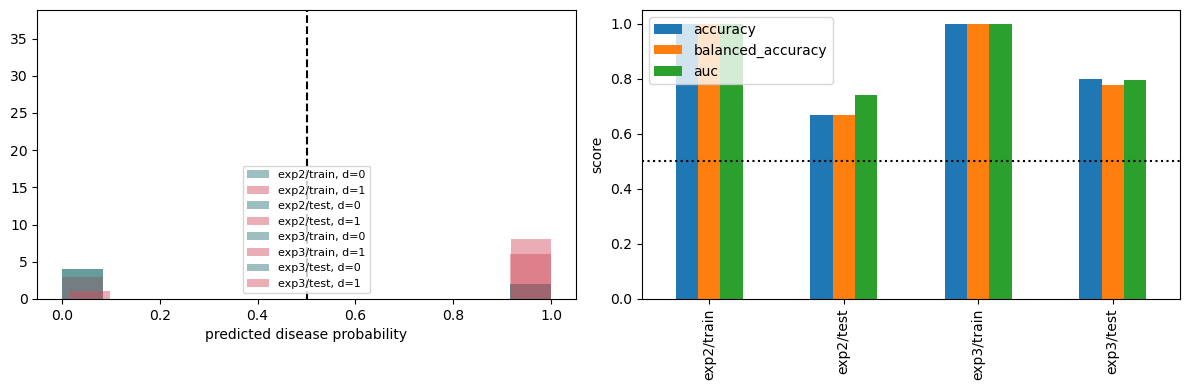

,accuracy,balanced_accuracy,auc,sensitivity,specificity
exp2/train,1.000000,1.000000,1.000000,1.000000,1.000000
exp2/test,0.666667,0.666667,0.740741,0.666667,0.666667
exp3/train,1.000000,1.000000,1.000000,1.000000,1.000000
exp3/test,0.800000,0.777778,0.796296,0.888889,0.666667


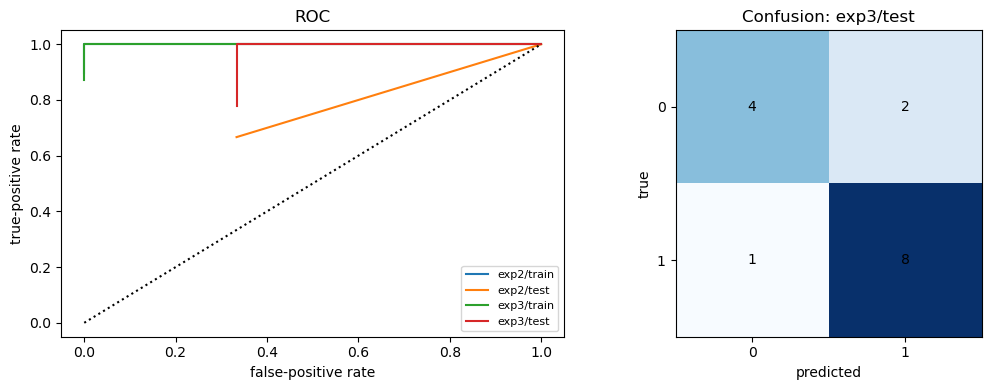

In [3]:
def latest_csv(folder, pattern):
    files = list(folder.glob(pattern))
    if not files:
        return None
    return max(files, key=lambda p: int(p.stem.rsplit('_', 1)[-1]))

def binary_metrics(frame):
    y = frame.true_diagnosis.to_numpy().astype(int)
    p = frame.predicted_probability.to_numpy().astype(float)
    pred = (p >= 0.5).astype(int)
    tp = np.sum((pred == 1) & (y == 1)); tn = np.sum((pred == 0) & (y == 0))
    fp = np.sum((pred == 1) & (y == 0)); fn = np.sum((pred == 0) & (y == 1))
    sens = tp / max(1, tp + fn); spec = tn / max(1, tn + fp)
    pos = p[y == 1]; neg = p[y == 0]
    auc = np.nan if not len(pos) or not len(neg) else np.mean(pos[:, None] > neg[None, :]) + 0.5 * np.mean(pos[:, None] == neg[None, :])
    return {'accuracy': np.mean(pred == y), 'balanced_accuracy': 0.5*(sens+spec), 'auc': auc, 'sensitivity': sens, 'specificity': spec}

diagnosis_frames = {}
for experiment_name, exp_dir in [('exp2', EXP2_EXP), ('exp3', E3_EXP)]:
    pred_dir = exp_dir / 'DiagnosisPredictions'
    for split_name, pattern in [('train', 'train_epoch_*.csv'), ('test', 'test_epoch_*.csv')]:
        path = latest_csv(pred_dir, pattern)
        key = f'{experiment_name}/{split_name}'
        if path is not None:
            frame = pd.read_csv(path)
            diagnosis_frames[key] = frame
            print(key, path.name, binary_metrics(frame))
        else:
            print(key, 'CSV not available yet')

if diagnosis_frames:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for split_name, frame in diagnosis_frames.items():
        for diagnosis, color in [(0, '#287271'), (1, '#d1495b')]:
            vals = frame.loc[frame.true_diagnosis == diagnosis, 'predicted_probability']
            axes[0].hist(vals, bins=12, alpha=.45, label=f'{split_name}, d={diagnosis}', color=color)
    axes[0].axvline(.5, color='black', ls='--'); axes[0].set_xlabel('predicted disease probability')
    axes[0].legend(fontsize=8)
    metric_table = pd.DataFrame({k: binary_metrics(v) for k, v in diagnosis_frames.items()}).T
    metric_table[['accuracy', 'balanced_accuracy', 'auc']].plot.bar(ax=axes[1], ylim=(0, 1.05))
    axes[1].axhline(.5, color='black', ls=':'); axes[1].set_ylabel('score')
    plt.tight_layout(); plt.show()
    display(metric_table)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for split_name, frame in diagnosis_frames.items():
        y = frame.true_diagnosis.to_numpy().astype(int); p = frame.predicted_probability.to_numpy()
        thresholds = np.linspace(1, 0, 201)
        tpr = [np.mean(p[y == 1] >= threshold) if np.any(y == 1) else np.nan for threshold in thresholds]
        fpr = [np.mean(p[y == 0] >= threshold) if np.any(y == 0) else np.nan for threshold in thresholds]
        axes[0].plot(fpr, tpr, label=split_name)
    axes[0].plot([0,1],[0,1], color='black', ls=':'); axes[0].set(xlabel='false-positive rate', ylabel='true-positive rate', title='ROC'); axes[0].legend(fontsize=8)
    test_name = 'exp3/test' if 'exp3/test' in diagnosis_frames else list(diagnosis_frames)[-1]
    test_frame = diagnosis_frames[test_name]; y = test_frame.true_diagnosis.to_numpy().astype(int); pred = (test_frame.predicted_probability.to_numpy() >= .5).astype(int)
    matrix = np.array([[np.sum((y==0)&(pred==0)), np.sum((y==0)&(pred==1))], [np.sum((y==1)&(pred==0)), np.sum((y==1)&(pred==1))]])
    axes[1].imshow(matrix, cmap='Blues'); axes[1].set(title=f'Confusion: {test_name}', xlabel='predicted', ylabel='true', xticks=[0,1], yticks=[0,1])
    for row in range(2):
        for column in range(2): axes[1].text(column, row, int(matrix[row,column]), ha='center', va='center')
    plt.tight_layout(); plt.show()

## Diagnosis learning curves

The Experiment 2 teacher-forcing coefficient should be 1 through epoch 100, decay to 0 at epoch 300, and remain 0 afterward.

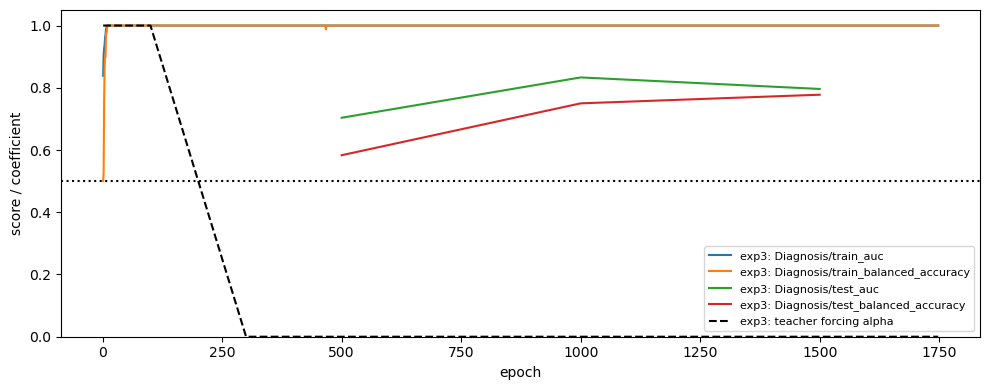

In [4]:
try:
    from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
    curve_tags = ['Diagnosis/train_auc', 'Diagnosis/train_balanced_accuracy', 'Diagnosis/test_auc', 'Diagnosis/test_balanced_accuracy']
    plt.figure(figsize=(10, 4))
    plotted = False
    for experiment_name, exp_dir in [('exp2', EXP2_EXP), ('exp3', E3_EXP)]:
        event_files = sorted((exp_dir / 'TensorBoard').glob('events.out.tfevents.*'))
        if not event_files:
            print(experiment_name, 'TensorBoard events are not available yet')
            continue
        accumulator = EventAccumulator(str(event_files[-1]), size_guidance={'scalars': 0})
        accumulator.Reload()
        scalar_tags = set(accumulator.Tags().get('scalars', []))
        for tag in curve_tags:
            if tag in scalar_tags:
                events = accumulator.Scalars(tag)
                plt.plot([e.step for e in events], [e.value for e in events], label=f'{experiment_name}: {tag}')
                plotted = True
        if experiment_name == 'exp3' and 'Diagnosis/teacher_forcing_alpha' in scalar_tags:
            events = accumulator.Scalars('Diagnosis/teacher_forcing_alpha')
            plt.plot([e.step for e in events], [e.value for e in events], color='black', ls='--', label='exp3: teacher forcing alpha')
            plotted = True
    if plotted:
        plt.ylim(0, 1.05); plt.axhline(.5, color='black', ls=':'); plt.xlabel('epoch'); plt.ylabel('score / coefficient'); plt.legend(fontsize=8); plt.tight_layout(); plt.show()
    else:
        plt.close()
except ImportError:
    print('tensorboard package is unavailable in this kernel')

## Latent component speeds

These are interval-average latent velocities over `[t, t+h]`. Experiment 2 has zero individual-age speed. Experiment 3 decomposes total age into population and baseline-derived individual terms.

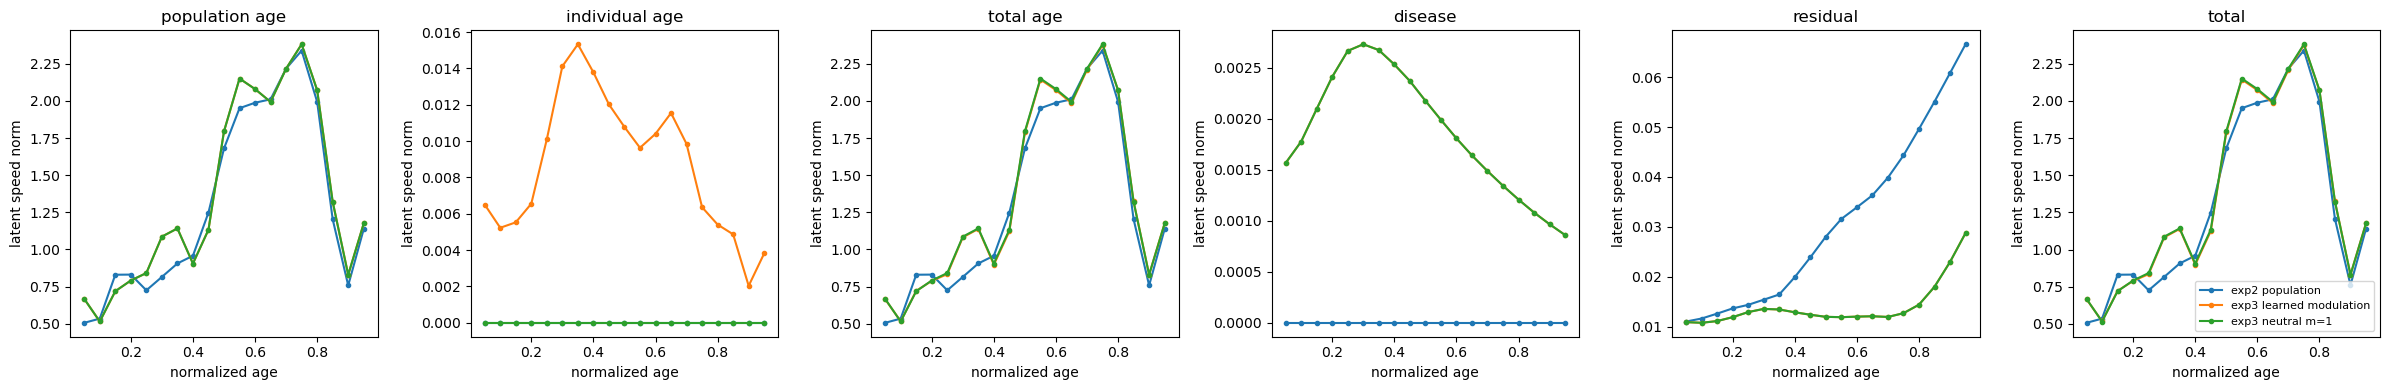

,model,age,gate,age_speed,population_age_speed,individual_age_speed,disease_speed,residual_speed,total_speed
0,exp2 population,0.05,3.588109e-09,0.506882,0.506882,0.0,2.399124e-09,0.011049,0.507002
1,exp2 population,0.10,3.588109e-09,0.534896,0.534896,0.0,2.760141e-09,0.011650,0.535023
2,exp2 population,0.15,3.588109e-09,0.830258,0.830258,0.0,3.408792e-09,0.012630,0.830354
3,exp2 population,0.20,3.588109e-09,0.831132,0.831132,0.0,4.202086e-09,0.013677,0.831245
4,exp2 population,0.25,3.588109e-09,0.725367,0.725367,0.0,4.895445e-09,0.014388,0.725509


In [5]:
def predicted_gate(model, z):
    flow = model['flow']
    if hasattr(flow, 'anchor_disease_probability'):
        with torch.no_grad():
            return flow.anchor_disease_probability(z).reshape(1, 1)
    return z.new_ones((1, 1))

def flow_condition(model, z, gate=None, modulation_mode='learned', donor_z=None):
    if gate is None:
        gate = predicted_gate(model, z)
    flow = model['flow']
    if not hasattr(flow, 'compose_condition'):
        return gate
    condition = flow.compose_condition(gate, z, detach_anchor=True)
    if condition.shape[1] > 1 and modulation_mode == 'neutral':
        condition[:, 1:] = 1.0
    elif condition.shape[1] > 1 and modulation_mode == 'donor':
        if donor_z is None:
            raise ValueError('donor_z is required for donor modulation')
        condition[:, 1:] = flow.age_modulation(donor_z, detach_anchor=True)
    return condition

def component_rows(name, model, gate=None, modulation_mode='learned', donor_z=None, age_grid=np.linspace(0.05, 0.95, 19), h=0.01):
    if not model['available']:
        return []
    z = model['mean_z']
    if gate is None:
        gate = predicted_gate(model, z)
    condition = flow_condition(model, z, gate, modulation_mode, donor_z)
    rows = []
    with torch.no_grad():
        for age in age_grid:
            s = z.new_tensor([[age]]); t = z.new_tensor([[age+h]])
            comp = model['flow'].velocity_components(z, s, t, age_cond=condition)
            rows.append({
                'model': name, 'age': age, 'gate': float(gate.item()),
                'age_speed': float(comp['age'].norm().item()),
                'population_age_speed': float(comp.get('age_population', comp['age']).norm().item()),
                'individual_age_speed': float(comp.get('age_individual', torch.zeros_like(comp['age'])).norm().item()),
                'disease_speed': float(comp['disease'].norm().item()),
                'residual_speed': float(comp['residual'].norm().item()),
                'total_speed': float(comp['velocity'].norm().item()),
            })
    return rows

speed_rows = []
speed_rows += component_rows('exp2 population', exp2_model)
speed_rows += component_rows('exp3 learned modulation', e3_model)
speed_rows += component_rows('exp3 neutral m=1', e3_model, modulation_mode='neutral')
speed_df = pd.DataFrame(speed_rows)
if not speed_df.empty:
    columns = ['population_age_speed','individual_age_speed','age_speed','disease_speed','residual_speed','total_speed']
    fig, axes = plt.subplots(1, 6, figsize=(24, 4), sharex=True)
    for ax, column, title in zip(axes, columns, ['population age','individual age','total age','disease','residual','total']):
        for model_name, frame in speed_df.groupby('model'):
            ax.plot(frame.age, frame[column], marker='o', ms=3, label=model_name)
        ax.set_title(title); ax.set_xlabel('normalized age'); ax.set_ylabel('latent speed norm')
    axes[-1].legend(fontsize=8); plt.tight_layout(); plt.show()
display(speed_df.head())

## Decoder-induced normal speed

For an INR `G(x,z)`, the local normal speed is

$$c_n(x)=-\frac{\nabla_zG(x,z)^T v}{\|\nabla_xG(x,z)\|+\epsilon}.$$

The finite-difference estimate uses `G(x,z)-G(x,z+h v)` divided by `h ||grad_x G||`. Agreement validates the Jacobian calculation and sign convention.

In [6]:
def decode(decoder, z, xyz, batch=32768):
    values = []
    with torch.no_grad():
        for start in range(0, len(xyz), batch):
            x = xyz[start:start+batch].to(DEVICE)
            values.append(decoder(torch.cat([z.expand(len(x), -1), x], dim=1)).cpu())
    return torch.cat(values).reshape(-1)

def near_surface_points(model, count=NUM_NEAR_SURFACE, candidates=RANDOM_CANDIDATES):
    xyz = torch.rand(candidates, 3) * 2.0 - 1.0
    sdf = decode(model['decoder'], model['mean_z'], xyz)
    keep = torch.topk(sdf.abs(), k=min(count, len(sdf)), largest=False).indices
    return xyz[keep].to(DEVICE)

def pad_component(component, kind, spec):
    a = int(spec['VelocityAgeDim']); d = int(spec['VelocityDiseaseDim']); r = int(spec['VelocityResidualDim'])
    out = component.new_zeros((component.shape[0], a+d+r))
    if kind in ('age', 'age_population', 'age_individual'): out[:, :a] = component
    elif kind == 'disease': out[:, a:a+d] = component
    elif kind == 'residual': out[:, a+d:] = component
    elif kind == 'total': out = component
    return out

def normal_speed(model, xyz, kind, gate=None, modulation_mode='learned', donor_z=None, age=AGE_START, h=AGE_STEP):
    z = model['mean_z'].detach()
    s = z.new_tensor([[age]]); t = z.new_tensor([[age+h]])
    with torch.no_grad():
        condition = flow_condition(model, z, gate, modulation_mode, donor_z)
        comp = model['flow'].velocity_components(z, s, t, age_cond=condition)
        if kind == 'total': value = comp['velocity']
        elif kind == 'age_population': value = comp.get('age_population', comp['age'])
        elif kind == 'age_individual': value = comp.get('age_individual', torch.zeros_like(comp['age']))
        else: value = comp[kind]
        v = pad_component(value, kind, model['spec'])
    x = xyz.detach().clone().requires_grad_(True)
    zz = z.expand(len(x), -1).detach().clone().requires_grad_(True)
    sdf = model['decoder'](torch.cat([zz, x], dim=1)).reshape(-1)
    grad_z, grad_x = torch.autograd.grad(sdf.sum(), (zz, x), create_graph=False)
    denom = grad_x.norm(dim=1).clamp_min(1e-8)
    jac = -(grad_z * v.expand(len(x), -1)).sum(dim=1) / denom
    with torch.no_grad():
        sdf_next = model['decoder'](torch.cat([zz.detach() + h*v.expand(len(x), -1), x.detach()], dim=1)).reshape(-1)
        fd = (sdf.detach() - sdf_next) / (h * denom.detach())
    return jac.detach().cpu().numpy(), fd.detach().cpu().numpy()

shape_speed_rows = []
for model_name, model in models.items():
    if not model['available']:
        continue
    xyz = near_surface_points(model)
    gate = predicted_gate(model, model['mean_z'])
    for kind in ['age_population', 'age_individual', 'age', 'disease', 'residual', 'total']:
        jac, fd = normal_speed(model, xyz, kind, gate)
        corr = np.corrcoef(jac, fd)[0,1] if np.std(jac) > 0 and np.std(fd) > 0 else np.nan
        rel = np.mean(np.abs(jac-fd)) / max(1e-8, np.mean(np.abs(fd)))
        shape_speed_rows.append({'model':model_name, 'component':kind, 'rms_jacobian':np.sqrt(np.mean(jac**2)), 'rms_finite_difference':np.sqrt(np.mean(fd**2)), 'correlation':corr, 'relative_error':rel})
shape_speed_df = pd.DataFrame(shape_speed_rows)
display(shape_speed_df)

,model,component,rms_jacobian,rms_finite_difference,correlation,relative_error
0,exp2_population_age,age_population,5.694350e-02,0.055208,0.985577,0.081512
1,exp2_population_age,age_individual,0.000000e+00,0.000000,NaN,0.000000
2,exp2_population_age,age,5.694350e-02,0.055208,0.985577,0.081512
3,exp2_population_age,disease,1.480389e-10,0.000000,NaN,0.011304
4,exp2_population_age,residual,1.154818e-03,0.001151,0.999794,0.004847
5,exp2_population_age,total,5.655660e-02,0.054890,0.985912,0.080535
6,exp3_personalized_age,age_population,5.035678e-02,0.050199,0.987613,0.076145
7,exp3_personalized_age,age_individual,3.220138e-04,0.000322,0.999916,0.002878
8,exp3_personalized_age,age,5.013428e-02,0.049983,0.987703,0.075984
9,exp3_personalized_age,disease,4.394596e-05,0.000044,0.999466,0.025775


## Signed shape-speed maps

These 3D near-surface maps use one shared symmetric color range per model. Negative and positive values indicate opposite normal directions under the Jacobian sign convention.

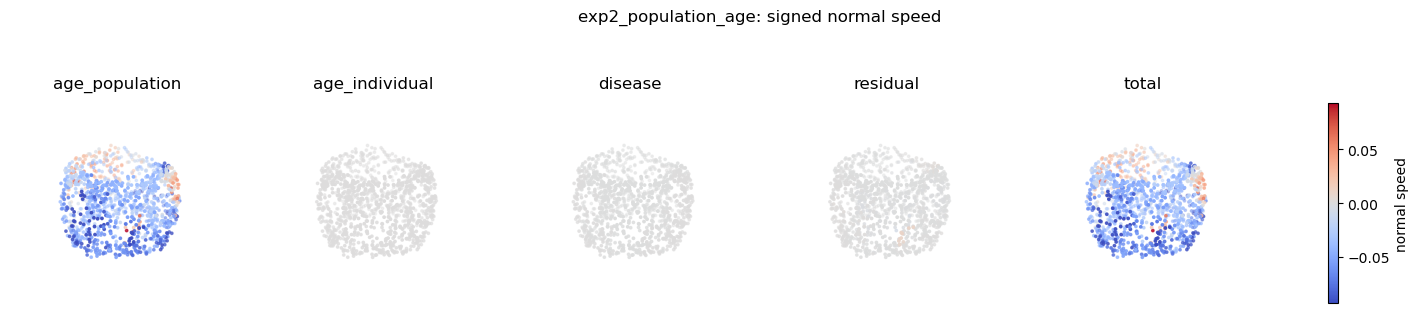

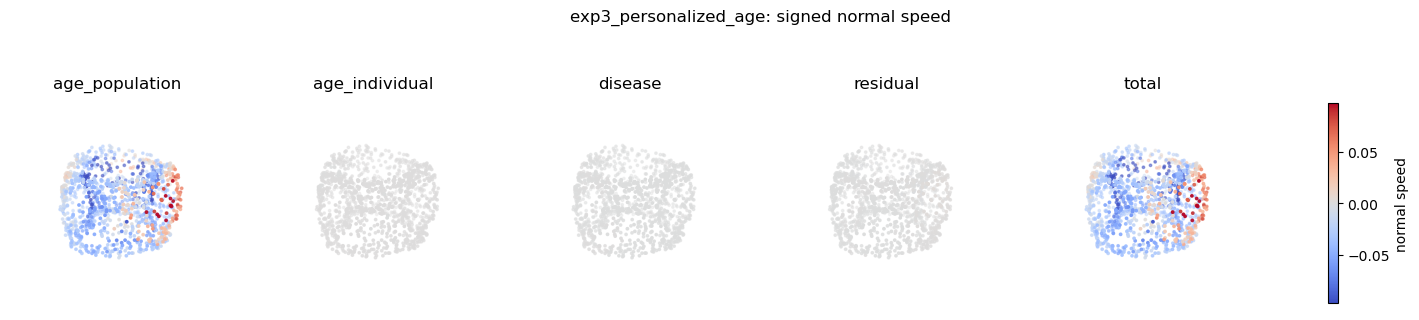

In [7]:
for model_name, model in models.items():
    if not model['available']:
        continue
    xyz = near_surface_points(model, count=1200, candidates=60000)
    gate = predicted_gate(model, model['mean_z'])
    maps = {}
    for kind in ['age_population', 'age_individual', 'disease', 'residual', 'total']:
        maps[kind] = normal_speed(model, xyz, kind, gate)[0]
    vmax = np.quantile(np.abs(np.concatenate(list(maps.values()))), 0.98)
    points = xyz.detach().cpu().numpy()
    fig = plt.figure(figsize=(20, 4))
    for index, kind in enumerate(['age_population', 'age_individual', 'disease', 'residual', 'total'], start=1):
        ax = fig.add_subplot(1, 5, index, projection='3d')
        scatter = ax.scatter(points[:,0], points[:,1], points[:,2], c=maps[kind], s=3, cmap='coolwarm', vmin=-vmax, vmax=vmax)
        ax.set_title(kind); ax.set_axis_off(); ax.view_init(elev=25, azim=45)
    fig.suptitle(f'{model_name}: signed normal speed')
    fig.colorbar(scatter, ax=fig.axes, shrink=.65, label='normal speed')
    plt.show()

## Residual shape-energy fraction and component separation

The residual fraction is computed from RMS normal speed, not latent norm. This detects whether the decoder amplifies the smaller 32D residual block.

component,age,age_individual,age_population,disease,residual,total,residual_fraction
model,,,,,,,
exp2_population_age,0.003243,0.000000e+00,0.003243,2.191550e-20,1.333605e-06,0.003199,0.000411
exp3_personalized_age,0.002513,1.036929e-07,0.002536,1.931247e-09,2.936692e-07,0.002546,0.000117


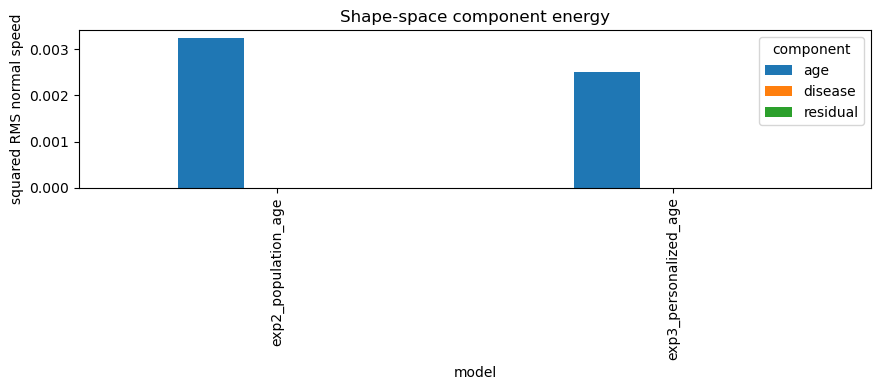

In [8]:
if not shape_speed_df.empty:
    energy = shape_speed_df.pivot(index='model', columns='component', values='rms_jacobian') ** 2
    energy['residual_fraction'] = energy['residual'] / (energy['age'] + energy['disease'] + energy['residual'] + 1e-12)
    display(energy)
    energy[['age','disease','residual']].plot.bar(figsize=(9,4), title='Shape-space component energy')
    plt.ylabel('squared RMS normal speed'); plt.tight_layout(); plt.show()

## Learned, neutral, and shuffled modulation

The learned modulation is the E3 model. Neutral modulation sets `m=1`, reproducing population aging inside the trained E3 model. Shuffled modulation assigns another training subject's modulation while retaining the original anchor and disease probability. Neutral and shuffled are evaluation modes, not additional training runs.

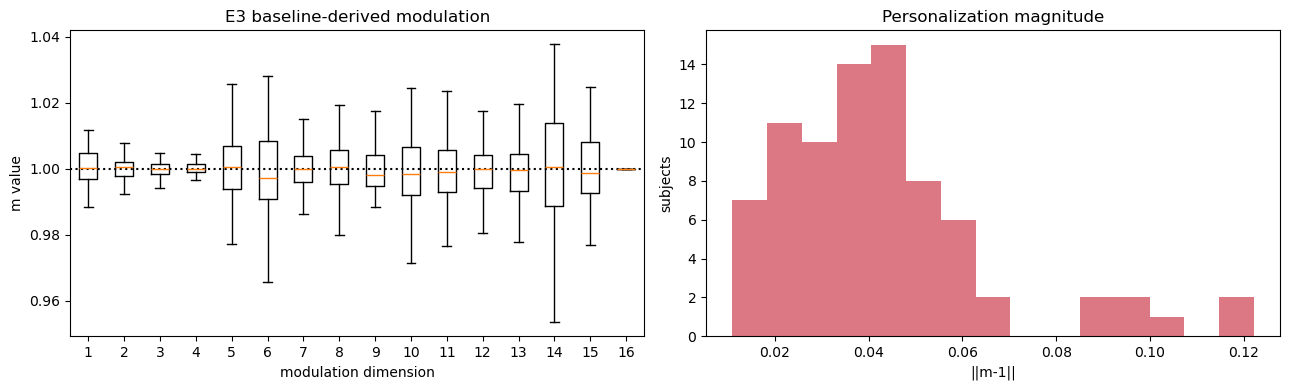

,mode,population_age_speed,individual_age_speed,total_age_speed
0,learned,1.160613,0.007627,1.160708
1,neutral,1.160613,0.000000,1.160613
2,shuffled,1.160613,0.007627,1.160708


In [9]:
if e3_model['available']:
    anchors = e3_model['all_z'].to(DEVICE)
    flow = e3_model['flow']
    with torch.no_grad():
        modulation = flow.age_modulation(anchors, detach_anchor=True)
        gates = flow.anchor_disease_probability(anchors)
        learned_condition = flow.compose_condition(gates, anchors, detach_anchor=True)
        neutral_condition = learned_condition.clone(); neutral_condition[:, 1:] = 1.0
        permutation = torch.randperm(len(anchors), device=DEVICE)
        shuffled_condition = learned_condition.clone(); shuffled_condition[:, 1:] = modulation[permutation]
        s = anchors.new_full((len(anchors), 1), 0.2)
        t = anchors.new_full((len(anchors), 1), 0.8)
        mode_rows = []
        for mode, condition in [('learned', learned_condition), ('neutral', neutral_condition), ('shuffled', shuffled_condition)]:
            comp = flow.velocity_components(anchors, s, t, age_cond=condition)
            mode_rows.append({
                'mode': mode,
                'population_age_speed': float(comp['age_population'].norm(dim=1).mean()),
                'individual_age_speed': float(comp['age_individual'].norm(dim=1).mean()),
                'total_age_speed': float(comp['age'].norm(dim=1).mean()),
            })
    modulation_np = modulation.cpu().numpy()
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].boxplot([modulation_np[:, index] for index in range(modulation_np.shape[1])], showfliers=False)
    axes[0].axhline(1.0, color='black', ls=':'); axes[0].set(xlabel='modulation dimension', ylabel='m value', title='E3 baseline-derived modulation')
    axes[1].hist(np.linalg.norm(modulation_np - 1.0, axis=1), bins=15, color='#d1495b', alpha=.75)
    axes[1].set(xlabel='||m-1||', ylabel='subjects', title='Personalization magnitude')
    plt.tight_layout(); plt.show()
    display(pd.DataFrame(mode_rows))
else:
    print('Experiment 3 checkpoint is unavailable.')

## Direct versus composed latent transition

This uses the same fixed disease gate and the same fixed Experiment 3 modulation for direct and composed paths. `age_composition_error` should be near floating-point precision; full latent composition also depends on disease and residual branches.

In [10]:
def transition(flow, z, s, t, condition):
    ss = z.new_tensor([[s]]); tt = z.new_tensor([[t]])
    return z + (tt-ss) * flow(z, ss, tt, age_cond=condition)

def age_displacement(model, z, s, t, condition):
    ss = z.new_tensor([[s]]); tt = z.new_tensor([[t]])
    comp = model['flow'].velocity_components(z, ss, tt, age_cond=condition)
    return (tt-ss) * comp['age']

rows = []
for model_name, model in models.items():
    if not model['available']:
        continue
    z = model['mean_z']
    gate = predicted_gate(model, z)
    condition = flow_condition(model, z, gate)
    with torch.no_grad():
        for s, r, t in [(0.1,0.3,0.8),(0.2,0.5,0.9),(0.05,0.15,0.4)]:
            direct = transition(model['flow'], z, s, t, condition)
            composed = transition(model['flow'], transition(model['flow'], z, s, r, condition), r, t, condition)
            age_direct = age_displacement(model, z, s, t, condition)
            age_composed = age_displacement(model, z, s, r, condition) + age_displacement(model, z, r, t, condition)
            rows.append({'model':model_name,'s':s,'r':r,'t':t,'age_composition_error':float((age_direct-age_composed).norm().item()),'latent_rmse':float(torch.mean((direct-composed)**2).sqrt().item()),'relative_error':float((direct-composed).norm().item() / max(1e-8,(direct-z).norm().item()))})
display(pd.DataFrame(rows))

,model,s,r,t,age_composition_error,latent_rmse,relative_error
0,exp2_population_age,0.10,0.30,0.8,6.116858e-08,0.000700,0.014357
1,exp2_population_age,0.20,0.50,0.9,7.436190e-08,0.001149,0.023724
2,exp2_population_age,0.05,0.15,0.4,2.172199e-08,0.000221,0.016232
3,exp3_personalized_age,0.10,0.30,0.8,5.460214e-08,0.000251,0.005428
4,exp3_personalized_age,0.20,0.50,0.9,7.395370e-08,0.000401,0.008624
5,exp3_personalized_age,0.05,0.15,0.4,1.915299e-08,0.000126,0.009055


## Optional one-/two-/three-shot label-free forecasting

Set `RUN_MULTISHOT = True` after the Experiment 3 checkpoint exists. For each subject and shot count, the first `K` scans optimize one anchor. Disease and modulation are inferred from that anchor, never copied from the test label. Compare the resulting CSV with Experiment 2 using the same subjects and settings.

This cell deliberately calls the trainer's anchor optimizer and transition helper so that notebook evaluation cannot silently drift from the training script.

In [11]:
RUN_MULTISHOT = False
MULTISHOT_SUBJECT_LIMIT = 20
MULTISHOT_OPTIMIZATION_STEPS = 1000
MULTISHOT_FIT_SAMPLES = 16384
MULTISHOT_SCORE_SAMPLES = 16384

def held_out_sdf_mae(decoder, latent, samples, clamp_dist, num_samples):
    data = deep_sdf.data.unpack_sdf_samples_from_ram(samples, int(num_samples)).to(DEVICE)
    xyz = data[:, :3]
    target = data[:, 3:4].clamp(-float(clamp_dist), float(clamp_dist))
    with torch.no_grad():
        pred = decoder(torch.cat([latent.expand(len(xyz), -1), xyz], dim=1))
        pred = pred.clamp(-float(clamp_dist), float(clamp_dist))
    return float(torch.mean(torch.abs(pred - target)).item())

multishot_df = pd.DataFrame()
if RUN_MULTISHOT:
    if not e3_model['available']:
        raise RuntimeError('Experiment 3 checkpoint is unavailable.')
    import deep_sdf
    import train_deep_sdf_longitudinal_flow_64_160_32_personal_age as e3_train

    spec = e3_model['spec']
    split = json.loads(Path(spec['TestSplit']).read_text())
    filenames = deep_sdf.data.get_instance_filenames(spec['DataSource'], split)
    time_map = e3_train._load_scan_age_map_from_labels(
        spec['LongitudinalTimeMetadataFile'], spec['LongitudinalTimeKey'])
    diagnosis_map = e3_train._load_scan_age_map_from_labels(
        spec['AgeMetadataFile'], spec['AgeConditionKey'])
    metadata = e3_train.build_longitudinal_metadata(
        filenames, spec.get('LongitudinalTimeNormalization', 'none'),
        scan_to_time_map=time_map, time_key_name=spec['LongitudinalTimeKey'])
    diagnosis = e3_train.build_scan_age_tensor(
        filenames, diagnosis_map, spec['AgeConditionKey'])
    subjects = {}
    for scan_index, subject_id in enumerate(metadata['subject_ids']):
        subjects.setdefault(subject_id, []).append(scan_index)
    rows = []
    for subject_id in sorted(subjects)[:MULTISHOT_SUBJECT_LIMIT]:
        scan_indices = sorted(
            subjects[subject_id],
            key=lambda index: float(metadata['timepoints_raw'][index]))
        if len(scan_indices) < 2:
            continue
        true_diagnosis = int(float(diagnosis[scan_indices[0]]) >= 0.5)
        cached_samples = {
            index: deep_sdf.data.read_sdf_samples_into_ram(
                e3_train._resolve_existing_file(filenames[index]))
            for index in scan_indices
        }
        for shots in spec.get('EvalObservedTimepointsList', [1, 2, 3]):
            shots = min(int(shots), len(scan_indices) - 1)
            observed = scan_indices[:shots]
            targets = scan_indices[shots:]
            observations = [
                {'samples': cached_samples[index],
                 'time': float(metadata['timepoints'][index])}
                for index in observed
            ]
            anchor, fit_history = e3_train.optimize_subject_anchor_from_observations(
                e3_model['decoder'], e3_model['flow'], spec['CodeLength'],
                observations, spec['ClampingDistance'],
                num_iterations=MULTISHOT_OPTIMIZATION_STEPS,
                num_samples=MULTISHOT_FIT_SAMPLES,
                lr=spec.get('EvalTestAnchorLR', 5e-3),
                init_std=spec.get('EvalTestAnchorInitStd', 0.01),
                code_reg_lambda=spec.get('EvalTestAnchorCodeRegLambda', 1e-4),
                code_bound=spec.get('CodeBound'),
                use_age_conditioning=spec.get('UseAgeConditioning', False),
                disease_condition_mode='predicted_soft',
                disease_threshold=spec.get('AnchorDiseaseThreshold', 0.5))
            with torch.no_grad():
                disease_probability = float(
                    e3_model['flow'].anchor_disease_probability(anchor).item())
            gate = anchor.new_tensor([[disease_probability]])
            condition = flow_condition(e3_model, anchor, gate)
            baseline_time = float(metadata['timepoints'][scan_indices[0]])
            for rollout in spec.get('EvalRolloutModes', ['direct', 'composed']):
                previous_z = anchor
                previous_time = baseline_time
                if rollout == 'composed' and observed:
                    previous_time = float(metadata['timepoints'][observed[-1]])
                    previous_z = e3_train._apply_temporal_flow_interval(
                        e3_model['flow'], anchor, baseline_time, previous_time,
                        max_dt=spec.get('EvalTestMaxRolloutDt', 0.0),
                        age_end_cond=condition)
                for target_index in targets:
                    target_time = float(metadata['timepoints'][target_index])
                    if rollout == 'direct':
                        target_z = e3_train._apply_temporal_flow_interval(
                            e3_model['flow'], anchor, baseline_time, target_time,
                            max_dt=spec.get('EvalTestMaxRolloutDt', 0.0),
                            age_end_cond=condition)
                    else:
                        target_z = e3_train._apply_temporal_flow_interval(
                            e3_model['flow'], previous_z, previous_time, target_time,
                            max_dt=spec.get('EvalTestMaxRolloutDt', 0.0),
                            age_end_cond=condition)
                        previous_z = target_z.detach()
                        previous_time = target_time
                    rows.append({
                        'subject_id': subject_id, 'shots': shots, 'rollout': rollout,
                        'target_scan': Path(filenames[target_index]).stem,
                        'target_time': target_time, 'true_diagnosis': true_diagnosis,
                        'predicted_probability': disease_probability,
                        'predicted_class': int(disease_probability >= 0.5),
                        'anchor_fit_final_loss': fit_history[-1] if fit_history else np.nan,
                        'forecast_sdf_mae': held_out_sdf_mae(
                            e3_model['decoder'], target_z, cached_samples[target_index],
                            spec['ClampingDistance'], MULTISHOT_SCORE_SAMPLES),
                    })
    multishot_df = pd.DataFrame(rows)
    output_dir = E3_EXP / 'Analysis'
    output_dir.mkdir(parents=True, exist_ok=True)
    multishot_df.to_csv(output_dir / 'multishot_label_free_forecast.csv', index=False)

if not multishot_df.empty:
    forecast_summary = multishot_df.groupby(['shots', 'rollout']).forecast_sdf_mae.agg(['mean', 'std', 'count'])
    diagnosis_subjects = multishot_df.drop_duplicates(['shots', 'subject_id'])
    diagnosis_summary = pd.DataFrame({
        shots: binary_metrics(frame)
        for shots, frame in diagnosis_subjects.groupby('shots')
    }).T
    display(forecast_summary)
    display(diagnosis_summary)
    multishot_df.groupby(['shots', 'rollout']).forecast_sdf_mae.mean().unstack().plot.bar(
        figsize=(8, 4), ylabel='held-out future SDF MAE', title='Label-free future prediction')
    plt.tight_layout(); plt.show()
else:
    print('Set RUN_MULTISHOT=True after training Experiment 3 to run this evaluation.')

Set RUN_MULTISHOT=True after training Experiment 3 to run this evaluation.


## Interpretation checklist

- The primary result is paired future error for Experiment 2 population aging versus Experiment 3 personalized aging on the same subjects and target scans.
- Experiment 3 should outperform its own neutral `m=1` mode; otherwise its learned personalization is unnecessary.
- Correct modulation should outperform matched shuffled modulation in future forecasting; otherwise the modulation is not meaningfully subject-specific.
- Age composition error should be near numerical precision. Full latent and shape composition can remain nonzero because disease and residual depend on the changing latent state.
- Check whether one-shot diagnosis and forecasting improve with two and three observations, but retain one-shot as the primary baseline-derived result.
- Require low Jacobian/finite-difference error before interpreting component speed maps.
- Individual-age diagnosis AUC should be measured with a held-out age-matched probe and should remain near 0.5.
- The 32D residual remains successful only if its diagnosis leakage and shape-energy fraction remain low.
- Inspect whether disease speed remains separated while residual diagnosis leakage and residual shape energy decrease.
- Report predicted-soft results as the primary label-free setting. Oracle diagnosis is an upper-bound ablation, not the main test result.